# Assignment 2.6 - Flow Matching from scratch (2D toy)

Du lieu: hon hop 8 Gaussian (8-mode) tren 2D.
- `VelocityNet(x_t, t) -> v`, train bang **Flow Matching loss** (rectified flow tuyen tinh)
- Sampling: **Euler** voi 1, 5, 10, 50 buoc
- Truc quan hoa quy dao -> kiem chung **thang hon DDPM**
- **Bonus Reflow:** sinh 10K cap (noise -> sample) tat dinh, train lai, so do cong quy dao truoc/sau

Tat ca hinh luu vao `output/`.

In [1]:
import os, math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", device)

device: cuda


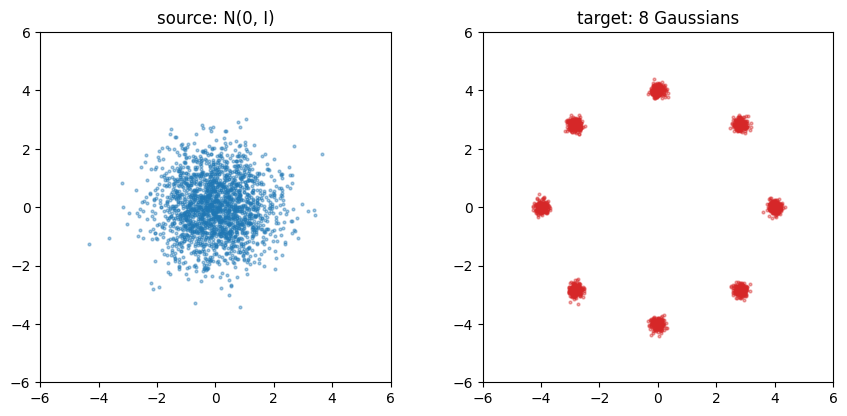

In [2]:
# ---- Du lieu: 8-mode Gaussian mixture & phan phoi nguon (noise N(0,I)) ----
def sample_8gaussians(n, std=0.12, radius=4.0):
    angles = 2 * math.pi * torch.arange(8) / 8
    centers = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)  # (8,2)
    idx = torch.randint(0, 8, (n,))
    return centers[idx] + std * torch.randn(n, 2)

def sample_noise(n):
    return torch.randn(n, 2)

# Plot du lieu vs noise -> output/fm_data.png
data = sample_8gaussians(2000)
noise = sample_noise(2000)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].scatter(noise[:, 0], noise[:, 1], s=4, alpha=0.4, color="C0"); ax[0].set_title("source: N(0, I)")
ax[1].scatter(data[:, 0], data[:, 1], s=4, alpha=0.4, color="C3"); ax[1].set_title("target: 8 Gaussians")
for a in ax: a.set_aspect("equal"); a.set_xlim(-6, 6); a.set_ylim(-6, 6)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fm_data.png"), dpi=150); plt.show()

In [3]:
# ---- VelocityNet(x_t, t) -> v ----
class VelocityNet(nn.Module):
    def __init__(self, dim=2, hidden=128, n_freq=8):
        super().__init__()
        self.register_buffer("freqs", (2.0 ** torch.arange(n_freq)) * math.pi)
        self.net = nn.Sequential(
            nn.Linear(dim + 2 * n_freq, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x, t):
        t = t.view(-1, 1)                                  # (B,1) trong [0,1]
        tf = torch.cat([torch.sin(t * self.freqs), torch.cos(t * self.freqs)], dim=-1)
        return self.net(torch.cat([x, tf], dim=-1))

iter 1000/6000 | loss 3.5363
iter 2000/6000 | loss 3.4663
iter 3000/6000 | loss 3.5165
iter 4000/6000 | loss 3.6896
iter 5000/6000 | loss 3.6041
iter 6000/6000 | loss 3.5938


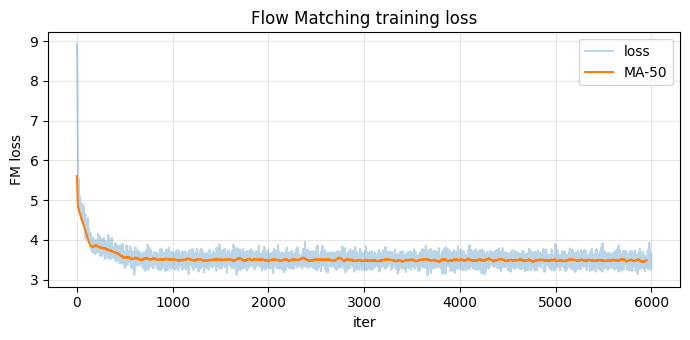

In [4]:
# ---- Train Flow Matching ----
# Path tuyen tinh: x_t = (1-t) x0 + t x1 ; target velocity = x1 - x0 (hang so)
def train_fm(net, n_iters=6000, batch=2048, lr=2e-3, pairs=None):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    losses = []
    for it in range(n_iters):
        if pairs is None:                       # FM thuong: ghep ngau nhien noise<->data
            x0 = sample_noise(batch).to(device)
            x1 = sample_8gaussians(batch).to(device)
        else:                                   # Reflow: dung cap (x0,x1) co dinh
            x0, x1 = pairs
            idx = torch.randint(0, x0.shape[0], (batch,), device=device)
            x0, x1 = x0[idx], x1[idx]
        t = torch.rand(batch, 1, device=device)
        xt = (1 - t) * x0 + t * x1
        target = x1 - x0
        v = net(xt, t)
        loss = ((v - target) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if (it + 1) % 1000 == 0:
            print(f"iter {it+1}/{n_iters} | loss {loss.item():.4f}")
    return losses

net = VelocityNet().to(device)
losses = train_fm(net)

# Luu bieu do loss -> output/fm_loss.png
plt.figure(figsize=(7, 3.5))
plt.plot(losses, alpha=0.3, label="loss")
ma = np.convolve(losses, np.ones(50) / 50, mode="valid")
plt.plot(range(len(ma)), ma, color="C1", label="MA-50")
plt.xlabel("iter"); plt.ylabel("FM loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Flow Matching training loss"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fm_loss.png"), dpi=150); plt.show()

In [5]:
# ---- Euler ODE sampler (t: 0 -> 1), tra ve ca quy dao ----
@torch.no_grad()
def euler_sample(net, x0, steps):
    x = x0.clone()
    traj = [x.clone()]
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((x.shape[0], 1), i * dt, device=device)
        x = x + net(x, t) * dt
        traj.append(x.clone())
    return x, torch.stack(traj)   # x_final, traj (steps+1, N, 2)

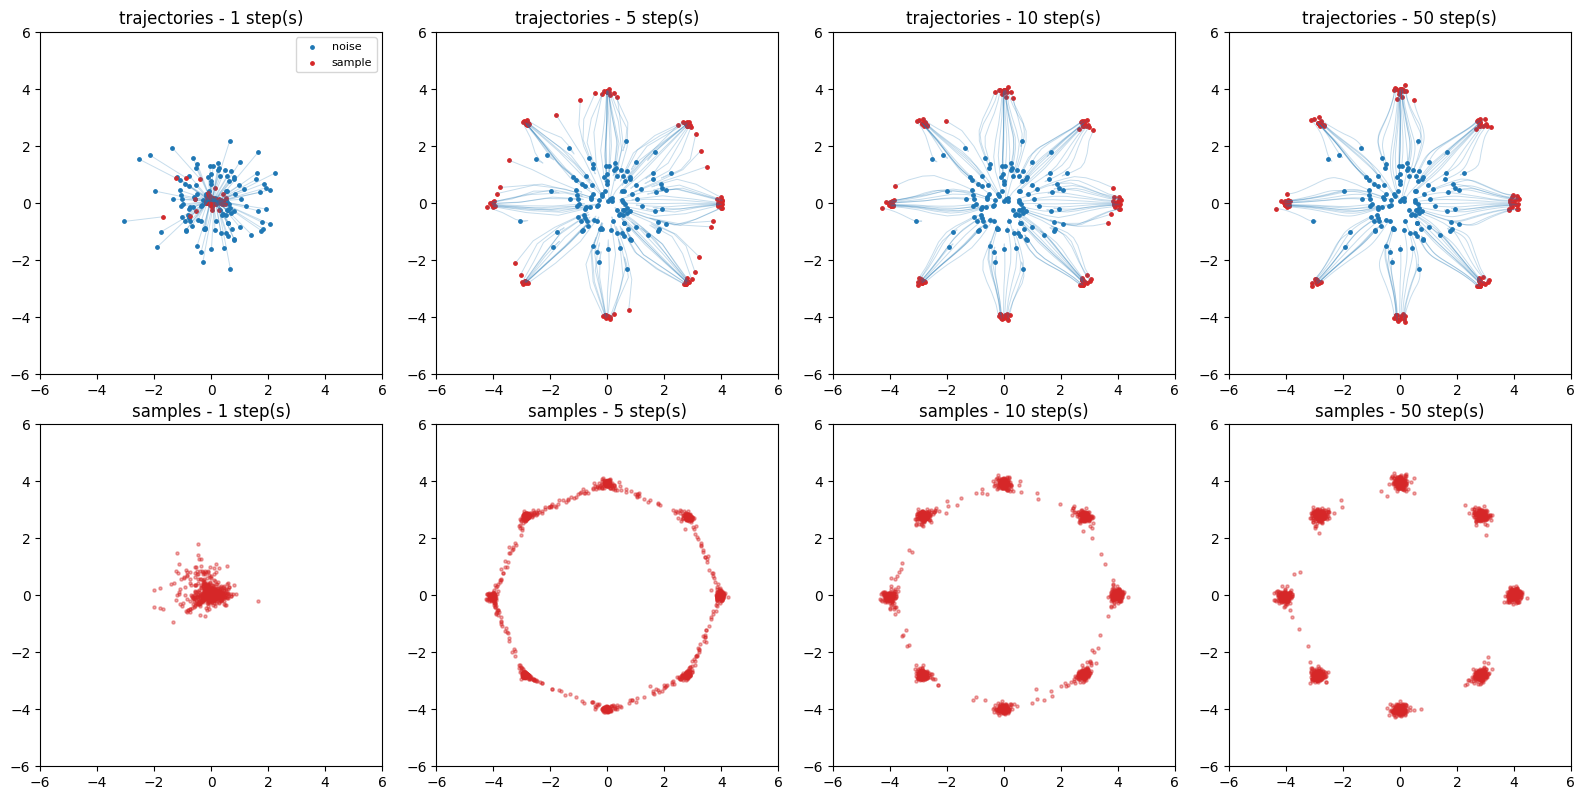

Nhan xet: quy dao FM gan nhu thang -> 5-10 buoc Euler da ra dung 8 mode.


In [6]:
# ---- Truc quan: quy dao & samples voi 1, 5, 10, 50 buoc ----
step_list = [1, 5, 10, 50]
x0_fixed = sample_noise(1500).to(device)
x0_traj = x0_fixed[:120]   # subset de ve duong quy dao cho de nhin

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for c, steps in enumerate(step_list):
    # hang 1: quy dao
    _, traj = euler_sample(net, x0_traj, steps)
    traj = traj.cpu().numpy()
    ax = axes[0, c]
    for k in range(traj.shape[1]):
        ax.plot(traj[:, k, 0], traj[:, k, 1], color="C0", alpha=0.25, lw=0.7)
    ax.scatter(traj[0, :, 0], traj[0, :, 1], s=6, color="C0", label="noise")
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=6, color="C3", label="sample")
    ax.set_title(f"trajectories - {steps} step(s)"); ax.set_aspect("equal")
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    # hang 2: chat luong samples
    xf, _ = euler_sample(net, x0_fixed, steps)
    xf = xf.cpu().numpy()
    axes[1, c].scatter(xf[:, 0], xf[:, 1], s=5, alpha=0.4, color="C3")
    axes[1, c].set_title(f"samples - {steps} step(s)"); axes[1, c].set_aspect("equal")
    axes[1, c].set_xlim(-6, 6); axes[1, c].set_ylim(-6, 6)
axes[0, 0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fm_trajectories.png"), dpi=150); plt.show()
print("Nhan xet: quy dao FM gan nhu thang -> 5-10 buoc Euler da ra dung 8 mode.")

## So sanh voi DDPM (cung du lieu 2D)

Train nhanh 1 DDPM (du doan noise) tren cung 8-Gaussian roi lay mau bang reverse process,
luu lai quy dao de so do **cong** voi Flow Matching.

In [7]:
# ---- DDPM 2D goi gon de so sanh ----
T = 200
beta = torch.linspace(1e-4, 0.02, T, device=device)
alpha = 1 - beta
abar = torch.cumprod(alpha, dim=0)

class EpsNet(nn.Module):
    def __init__(self, dim=2, hidden=128, n_freq=8):
        super().__init__()
        self.register_buffer("freqs", (2.0 ** torch.arange(n_freq)) * math.pi)
        self.net = nn.Sequential(
            nn.Linear(dim + 2 * n_freq, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim))
    def forward(self, x, t):                       # t: so nguyen [0,T)
        tn = (t.float() / T).view(-1, 1)
        tf = torch.cat([torch.sin(tn * self.freqs), torch.cos(tn * self.freqs)], dim=-1)
        return self.net(torch.cat([x, tf], dim=-1))

eps_net = EpsNet().to(device)
opt = torch.optim.Adam(eps_net.parameters(), lr=2e-3)
for it in range(6000):
    x0 = sample_8gaussians(2048).to(device)
    t = torch.randint(0, T, (2048,), device=device)
    e = torch.randn_like(x0)
    a = abar[t].view(-1, 1)
    xt = torch.sqrt(a) * x0 + torch.sqrt(1 - a) * e
    loss = ((eps_net(xt, t) - e) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    if (it + 1) % 2000 == 0:
        print(f"ddpm iter {it+1} | loss {loss.item():.4f}")

@torch.no_grad()
def ddpm_sample(eps_net, n, record_every=1):
    x = torch.randn(n, 2, device=device)
    traj = [x.clone()]
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device)
        e = eps_net(x, t)
        a = alpha[ti]; ab = abar[ti]; b = beta[ti]
        mean = (1 / torch.sqrt(a)) * (x - (b / torch.sqrt(1 - ab)) * e)
        x = mean + (torch.sqrt(b) * torch.randn_like(x) if ti > 0 else 0)
        if ti % record_every == 0:
            traj.append(x.clone())
    return x, torch.stack(traj)

ddpm iter 2000 | loss 0.4150
ddpm iter 4000 | loss 0.4128
ddpm iter 6000 | loss 0.4225


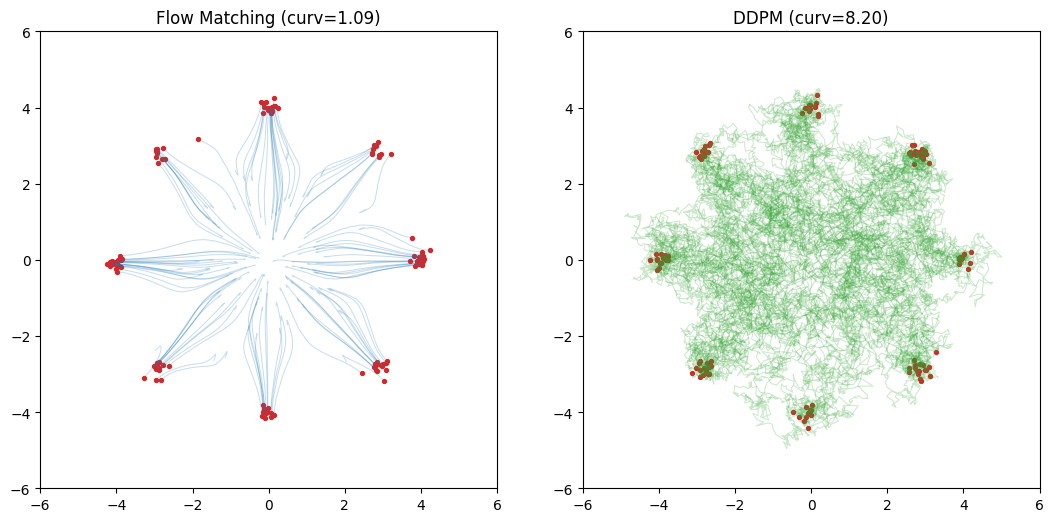

Curvature  FM=1.086  vs  DDPM=8.205  -> FM thang hon (gan 1 hon).


In [8]:
# ---- Quy dao FM vs DDPM + chi so cong (path length / chord length) ----
def curvature_ratio(traj):
    seg = (traj[1:] - traj[:-1]).norm(dim=-1).sum(0)     # do dai duong di
    chord = (traj[-1] - traj[0]).norm(dim=-1) + 1e-8     # khoang cach hai dau
    return (seg / chord)                                  # >=1, cang gan 1 cang thang

x0_cmp = sample_noise(120).to(device)
_, traj_fm = euler_sample(net, x0_cmp, 50)
_, traj_ddpm = ddpm_sample(eps_net, 120)

cur_fm = curvature_ratio(traj_fm).mean().item()
cur_ddpm = curvature_ratio(traj_ddpm).mean().item()

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
for tr, a, title, col in [(traj_fm, ax[0], f"Flow Matching (curv={cur_fm:.2f})", "C0"),
                          (traj_ddpm, ax[1], f"DDPM (curv={cur_ddpm:.2f})", "C2")]:
    tr = tr.cpu().numpy()
    for k in range(tr.shape[1]):
        a.plot(tr[:, k, 0], tr[:, k, 1], color=col, alpha=0.25, lw=0.7)
    a.scatter(tr[-1, :, 0], tr[-1, :, 1], s=8, color="C3")
    a.set_title(title); a.set_aspect("equal"); a.set_xlim(-6, 6); a.set_ylim(-6, 6)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fm_vs_ddpm.png"), dpi=150); plt.show()
print(f"Curvature  FM={cur_fm:.3f}  vs  DDPM={cur_ddpm:.3f}  -> FM thang hon (gan 1 hon).")

## Bonus - Reflow

1. Dung model FM da train sinh **10K cap tat dinh** (noise x0 -> sample x1 qua Euler nhieu buoc).
2. Train lai model tren chinh cac cap nay (couplings co dinh) -> quy dao duoc "lam thang".
3. So **do cong** quy dao truoc vs sau Reflow.

In [9]:
# ---- Sinh 10K cap tat dinh & train lai (Reflow) ----
N_PAIRS = 10000
with torch.no_grad():
    x0_pairs = sample_noise(N_PAIRS).to(device)
    x1_pairs, _ = euler_sample(net, x0_pairs, 50)     # tat dinh
print("Da sinh", N_PAIRS, "cap (noise -> sample).")

net_reflow = VelocityNet().to(device)
losses_rf = train_fm(net_reflow, n_iters=6000, pairs=(x0_pairs, x1_pairs))

Da sinh 10000 cap (noise -> sample).
iter 1000/6000 | loss 0.0145
iter 2000/6000 | loss 0.0056
iter 3000/6000 | loss 0.0042
iter 4000/6000 | loss 0.0028
iter 5000/6000 | loss 0.0021
iter 6000/6000 | loss 0.0016


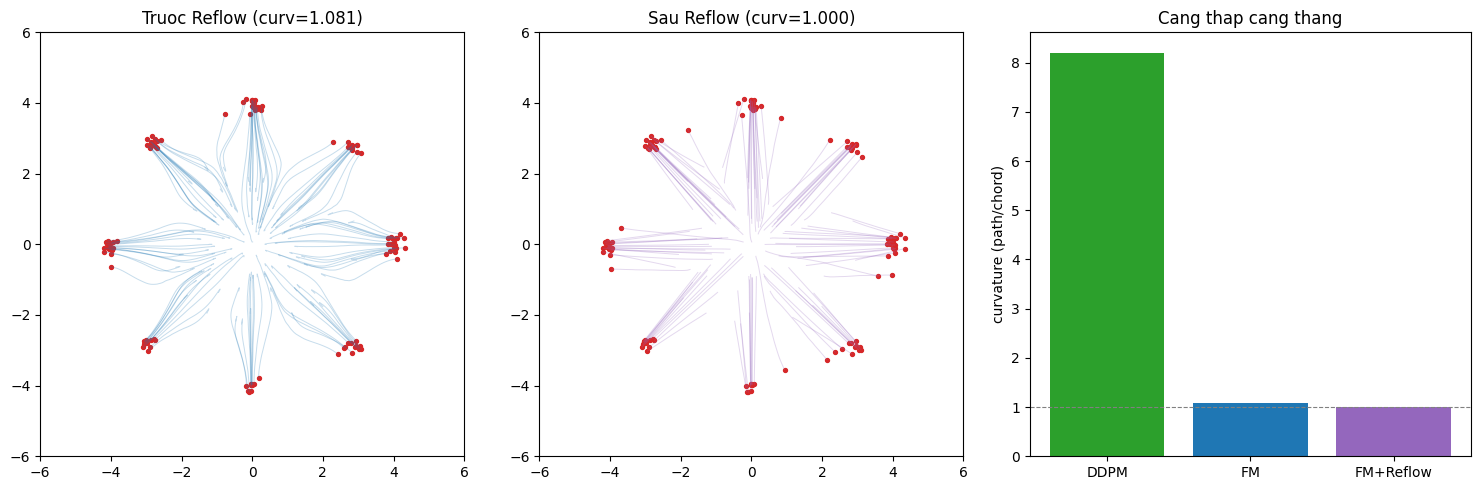

Curvature: DDPM=8.205 | FM=1.081 | FM+Reflow=1.000
Reflow lam quy dao thang hon nua -> sampling it buoc van chinh xac.


In [10]:
# ---- So do cong truoc vs sau Reflow ----
x0_eval = sample_noise(500).to(device)
_, traj_before = euler_sample(net, x0_eval, 50)
_, traj_after = euler_sample(net_reflow, x0_eval, 50)
cur_before = curvature_ratio(traj_before).mean().item()
cur_after = curvature_ratio(traj_after).mean().item()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for tr, a, title, col in [(traj_before, ax[0], f"Truoc Reflow (curv={cur_before:.3f})", "C0"),
                          (traj_after, ax[1], f"Sau Reflow (curv={cur_after:.3f})", "C4")]:
    trn = tr[:, :120].cpu().numpy()
    for k in range(trn.shape[1]):
        a.plot(trn[:, k, 0], trn[:, k, 1], color=col, alpha=0.25, lw=0.7)
    a.scatter(trn[-1, :, 0], trn[-1, :, 1], s=8, color="C3")
    a.set_title(title); a.set_aspect("equal"); a.set_xlim(-6, 6); a.set_ylim(-6, 6)
ax[2].bar(["DDPM", "FM", "FM+Reflow"], [cur_ddpm, cur_before, cur_after],
          color=["C2", "C0", "C4"])
ax[2].set_ylabel("curvature (path/chord)"); ax[2].set_title("Cang thap cang thang")
ax[2].axhline(1.0, color="gray", ls="--", lw=0.8)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "reflow_curvature.png"), dpi=150); plt.show()
print(f"Curvature: DDPM={cur_ddpm:.3f} | FM={cur_before:.3f} | FM+Reflow={cur_after:.3f}")
print("Reflow lam quy dao thang hon nua -> sampling it buoc van chinh xac.")

## Ket luan

- Flow Matching hoc truong van toc theo path tuyen tinh nen quy dao **gan nhu thang**;
  Euler chi 5-10 buoc da sinh dung 8 mode, trong khi DDPM can hang tram buoc va quy dao **cong/nhieu**.
- Chi so `path/chord` xac nhan: **DDPM > FM > FM+Reflow** (cang gan 1 cang thang).
- **Reflow** dung couplings tat dinh de "duoi thang" quy dao -> giam so buoc sampling can thiet.

Hinh da luu: `fm_data.png`, `fm_loss.png`, `fm_trajectories.png`, `fm_vs_ddpm.png`, `reflow_curvature.png`.